Author: [Mohit Saharan](https://linkedin.com/in/msaharan)

# Tabular foundation models: TabPFN, TabICLv2, and classical supervised ML

This notebook compares TabPFN and TabICLv2 with classical supervised machine learning models on classification, regression, probability-surface, and predictive-interval examples.

References used while preparing this notebook:

- TabICL GitHub repository examples (commit: 3b0c68074933bb3a602f757901dea4dc228ff84f)
- TabPFN GitHub repository hands-on demo notebook (commit: eaefd29252a0897bd644c1840934b34ce08e194f)

## Notebook scope

This notebook focuses on supervised tabular machine learning.

We will cover five supervised examples:

1. Binary classification on the Parkinson's disease dataset, comparing TabICLv2, TabPFN, and classical models.
2. Regression on the Boston Housing dataset, comparing TabICLv2, TabPFN, and classical models.
3. SHAP and representation comparisons for TabPFN and TabICLv2 on the same dataset.
4. Classification probability surfaces on a noisy two-moons dataset.
5. Quantile regression on a heteroscedastic 1D dataset, comparing TabICLv2 and TabPFN predictive intervals.

Kaggle note: enable Internet before running this notebook. `tabicl` and `tabpfn` download pretrained checkpoints on first use.

In [ ]:
# Kaggle / Colab setup.
# If imports fail after installation, restart the kernel and run from the imports cell.
# !uv pip install -q -U 'tabicl[shap]' tabpfn tabpfn-client xgboost catboost datasets rich 

## Base library Installation
# Install Baselines for model comparison
!uv pip install catboost xgboost

# Install the datasets library for loading example data
!uv pip install datasets

# Install rich for better and more readable printing
!uv pip install rich

## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!uv pip install tabpfn-client

# Install TabPFN extensions for additional functionalities
!uv pip install 'tabpfn-extensions[all]'

# Install tabpfn
!uv pip install tabpfn

# Install TabICL with SHAP extras
!uv pip install 'tabicl[shap]'

# Necessary Imports for the Notebook [Running this cell required!]

Now that the libraries are installed, let's import all the necessary modules for this notebook.

In [ ]:
# Standard Library Imports
import io
import os
import requests
import time
import warnings
import zipfile

# Hugging Face authentication for TabICL checkpoint downloads.
# In Kaggle, add a secret named HF_TOKEN. The checkpoint is public, so this
# is optional, but it avoids anonymous-request warnings and lower rate limits.
hf_token = os.environ.get("HF_TOKEN")

if not hf_token:
    try:
        from kaggle_secrets import UserSecretsClient

        hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        pass

if not hf_token:
    try:
        from google.colab import userdata

        hf_token = userdata.get("HF_TOKEN")
    except Exception:
        pass

if hf_token:
    os.environ["HF_TOKEN"] = hf_token
    print("HF_TOKEN found. Hugging Face downloads will use authenticated requests.")
else:
    print("HF_TOKEN not found. Hugging Face downloads will use anonymous requests.")

# TabPFN and Extensions

try:
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )

    from tabpfn import TabPFNClassifier, TabPFNRegressor
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

from tabicl import TabICLClassifier, TabICLRegressor

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.special import expit
from scipy.stats import t as student_t

# Other ML Models
from catboost import CatBoostClassifier, CatBoostRegressor

# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.rule import Rule
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import make_column_selector, make_column_transformer

# Scikit-Learn: Data & Preprocessing
from sklearn.datasets import fetch_openml, load_breast_cancer, load_diabetes, make_moons

# Scikit-Learn: Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier, XGBRegressor

# This transformer will be used to handle categorical features for the baseline models
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)

warnings.filterwarnings("ignore")

# Backend Selection [Running this cell required!]

TabPFN can be run in two ways: locally on your machine (if you have a GPU) or by using the TabPFN client, which sends the data to a server for computation.
In your project you would either use the **local** version (which requires a GPU) with:
```python
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

or the **client** API (which uses a remote server):

```python
# Simple import for TabPFN
from tabpfn_client import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

If you select **local** and it's your first time using the model, you'll need to accept the license agreement and log into Hugging Face.
You'll be prompted with instructions on how to do this the first time you fit the model.

For demonstration purposes, the cell below provides an interactive way to switch between local mode and the client.


In [ ]:
# Authentication code - No need to read it!

console = Console()

console.print(Panel.fit("[bold magenta]TabPFN Demo: Backend Selection[/bold magenta]"))
console.print("\nThis script can run TabPFN using one of two backends:")
console.print("  [bold]local:[/bold] Uses a local GPU (NVIDIA). Requires CUDA.")
console.print(
    "  [bold]client:[/bold] Uses the TabPFN API. Requires an internet connection and a free account."
)

backend = "local" # to use local (Kaggle/Colab) GPUs by default. 
# backend = None # uncomment to select between local and client backend at runtime.
while backend is None:
  console.print(
      "\n[bold]Choose your backend[/bold]: - If no text box is shown, restart the cell.",
  )
  user_input = input("Enter 'local' or 'client' and press return:")
  if user_input not in ["local", "client"]:
    continue
  backend = user_input

console.print(
    f"\n✅ You have selected the '[bold green]{backend}[/bold green]' backend."
)

console.print(Rule(f"[bold]Setting up [cyan]{backend}[/cyan] backend[/bold]"))

if backend == "local":
    console.print("Attempting local backend setup...")
    import torch

    if not torch.cuda.is_available():
        console.print(
            "[bold red]Error:[/bold red] GPU device not found. For fast training, please enable GPU.",
            style="red",
        )
        console.print(
            "In Colab: Go to [bold]Runtime -> Change runtime type -> Hardware accelerator -> GPU.[/bold]",
            style="yellow",
        )
        raise SystemError("GPU device not found.")
    console.print("[bold green]✅ GPU is available.[/bold green]")

    # --- Prior Labs Authentication ---
    console.print(Rule("[bold]Prior Labs Authentication[/bold]"))
    console.print(
        "\nTabPFN model weights require a free [bold]Prior Labs account[/bold] and "
        "acceptance of the non-commercial license.\n"
    )

    import os
    import getpass

    tabpfn_token = None

    # 1. Try Colab secret TABPFN_TOKEN
    try:
        from kaggle_secrets import UserSecretsClient
        tabpfn_token = UserSecretsClient().get_secret("TABPFN_TOKEN")
        if tabpfn_token:
            os.environ["TABPFN_TOKEN"] = tabpfn_token
            console.print("[bold green]✅ Found TABPFN_TOKEN in Kaggle secrets.[/bold green]")
    except Exception:
        pass
        
    # 2. Try Colab secret TABPFN_TOKEN
    try:
        from google.colab import userdata
        tabpfn_token = userdata.get("TABPFN_TOKEN")
        if tabpfn_token:
            os.environ["TABPFN_TOKEN"] = tabpfn_token
            console.print("[bold green]✅ Found TABPFN_TOKEN in Colab secrets.[/bold green]")
    except Exception:
        pass

    # 3. If no token found, prompt the user
    if not tabpfn_token:
        console.print(
            Panel(
                "To get your access token:\n\n"
                "  1. Go to [link=https://ux.priorlabs.ai]ux.priorlabs.ai[/link] and sign up / log in\n"
                "  2. Accept the license at [link=https://ux.priorlabs.ai/account/licenses]ux.priorlabs.ai/account/licenses[/link]\n"
                "  3. Copy your Access Token from [link=https://ux.priorlabs.ai/account]ux.priorlabs.ai/account[/link]\n\n"
                "[bold yellow]Tip:[/bold yellow] Save the token as a Colab secret named "
                "[bold cyan]TABPFN_TOKEN[/bold cyan] to skip this step next time.",
                title="[bold]🔑 Prior Labs Access Token required",
                border_style="blue",
            )
        )
        while not tabpfn_token:
            token_input = getpass.getpass("Paste your TABPFN_TOKEN and press Enter: ")
            if token_input.strip():
                tabpfn_token = token_input.strip()
                os.environ["TABPFN_TOKEN"] = tabpfn_token
            else:
                console.print("[red]Token cannot be empty. Please try again.[/red]")

    console.print("")
    console.print("Importing local TabPFN library...")

    from tabpfn import TabPFNClassifier, TabPFNRegressor

    console.print("[bold green]✅ TabPFN (local) imported successfully.[/bold green]")
elif backend == "client":
    console.print("Attempting client backend setup...")
    console.print("Importing TabPFN client library...")
    from tabpfn_client import TabPFNClassifier, TabPFNRegressor, init

    init()
    console.print("[bold green]✅ TabPFN (client) initialized.[/bold green]")


╭────────────────────────────────╮
│ TabPFN Demo: Backend Selection │
╰────────────────────────────────╯

This script can run TabPFN using one of two backends:

local: Uses a local GPU (NVIDIA). Requires CUDA.

client: Uses the TabPFN API. Requires an internet connection and a free account.

✅ You have selected the 'local' backend.

...

──────────────────────────────────────────── Prior Labs Authentication ────────────────────────────────────────────

TabPFN model weights require a free Prior Labs account and acceptance of the non-commercial license.

✅ Found TABPFN_TOKEN in Kaggle secrets.

Importing local TabPFN library...

✅ TabPFN (local) imported successfully.

In [ ]:
SEED = 42

# Keep True while building/debugging the notebook. Set False for final Kaggle figures.
FAST_MODE = True

# Runtime/quality knobs. TabICL's default is 8 estimators, but 4 is a good
# final-demo compromise on Kaggle T4. Use 8 only if runtime is acceptable.
N_TFM_ESTIMATORS = 2 if FAST_MODE else 4
CV_SPLITS = 5
CV_REPEATS = 2 if FAST_MODE else 5
GRID_POINTS_PER_AXIS = 60 if FAST_MODE else 100
HETEROSCEDASTIC_SAMPLES = 1200 if FAST_MODE else 3000

try:
    CUDA_AVAILABLE = torch.cuda.is_available()
    CUDA_DEVICE_COUNT = torch.cuda.device_count() if CUDA_AVAILABLE else 0
except Exception:
    CUDA_AVAILABLE = False
    CUDA_DEVICE_COUNT = 0

if CUDA_AVAILABLE:
    TABICL_DEVICE = "cuda:0"
    TABPFN_DEVICE = [f"cuda:{i}" for i in range(CUDA_DEVICE_COUNT)]
else:
    TABICL_DEVICE = "cpu"
    TABPFN_DEVICE = "cpu"

# Backward-compatible alias for non-foundation-model code and printouts.
DEVICE = TABICL_DEVICE

print(f"CUDA available: {CUDA_AVAILABLE}")
print(f"CUDA device count: {CUDA_DEVICE_COUNT}")
print(f"TabICL device: {TABICL_DEVICE}")
print(f"TabPFN device(s): {TABPFN_DEVICE}")
print(f"TFM ensemble members: {N_TFM_ESTIMATORS}")
print(f"CV folds x repeats: {CV_SPLITS}x{CV_REPEATS}")
print(f"Grid points per axis: {GRID_POINTS_PER_AXIS}")
print(f"Heteroscedastic samples: {HETEROSCEDASTIC_SAMPLES}")

In [ ]:
# Helper functions
# These keep the benchmark code sklearn-like while adding
# device-aware TabICLv2 and TabPFN constructors.

def tabicl_batch_size():
    return 1 if TABICL_DEVICE == "cpu" else 4


def make_tabicl_classifier(**overrides):
    params = {
        "n_estimators": N_TFM_ESTIMATORS,
        "device": TABICL_DEVICE,
        "random_state": SEED,
        "batch_size": tabicl_batch_size(),
    }
    params.update(overrides)
    return TabICLClassifier(**params)


def make_tabicl_regressor(**overrides):
    params = {
        "n_estimators": N_TFM_ESTIMATORS,
        "device": TABICL_DEVICE,
        "random_state": SEED,
        "batch_size": tabicl_batch_size(),
    }
    params.update(overrides)
    return TabICLRegressor(**params)


def make_tabpfn_classifier(**overrides):
    params = {
        "n_estimators": N_TFM_ESTIMATORS,
        "device": TABPFN_DEVICE,
        "random_state": SEED,
    }
    params.update(overrides)
    return TabPFNClassifier(**params)


def make_tabpfn_regressor(**overrides):
    params = {
        "n_estimators": N_TFM_ESTIMATORS,
        "device": TABPFN_DEVICE,
        "random_state": SEED,
    }
    params.update(overrides)
    return TabPFNRegressor(**params)


def classification_model_list():
    return [
        ("TabICLv2", make_tabicl_classifier()),
        ("TabPFN", make_tabpfn_classifier()),
        (
            "RandomForest",
            make_pipeline(column_transformer, RandomForestClassifier(random_state=SEED)),
        ),
        (
            "XGBoost",
            make_pipeline(
                column_transformer,
                XGBClassifier(random_state=SEED, eval_metric="logloss"),
            ),
        ),
        (
            "CatBoost",
            make_pipeline(
                column_transformer,
                CatBoostClassifier(
                    random_seed=SEED,
                    verbose=0,
                    allow_writing_files=False,
                ),
            ),
        ),
    ]


def regression_model_list():
    return [
        ("TabICLv2", make_tabicl_regressor()),
        ("TabPFN", make_tabpfn_regressor()),
        (
            "RandomForest",
            make_pipeline(column_transformer, RandomForestRegressor(random_state=SEED)),
        ),
        (
            "XGBoost",
            make_pipeline(
                column_transformer,
                XGBRegressor(random_state=SEED, objective="reg:squarederror"),
            ),
        ),
        (
            "CatBoost",
            make_pipeline(
                column_transformer,
                CatBoostRegressor(
                    random_seed=SEED,
                    verbose=0,
                    allow_writing_files=False,
                ),
            ),
        ),
    ]


def positive_class_proba(estimator, X):
    proba = estimator.predict_proba(X)
    if proba.ndim != 2 or proba.shape[1] < 2:
        raise ValueError("Expected a two-column probability array for binary classification.")
    return proba[:, 1]


def predict_proba_in_chunks(estimator, X, chunk_size=2048):
    chunks = []
    for start in range(0, X.shape[0], chunk_size):
        stop = start + chunk_size
        chunks.append(positive_class_proba(estimator, X[start:stop]))
    return np.concatenate(chunks)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mean_ci95(scores):
    scores = np.asarray(scores)
    mean = scores.mean()
    if len(scores) < 2:
        return mean, 0.0
    t_crit = student_t.ppf(0.975, df=len(scores) - 1)
    return mean, t_crit * scores.std(ddof=1) / np.sqrt(len(scores))


def coerce_quantile_array(prediction):
    # TabPFN returns a list of arrays for quantiles; TabICL returns a 2D array.
    if isinstance(prediction, list):
        return np.column_stack(prediction)
    return np.asarray(prediction)

# Classification with TabPFN and TabICLv2

### **Loading Parkinson’s Disease Dataset**

**Source:**  
The dataset was created by _Max Little_ of the **University of Oxford**, in collaboration with the **National Centre for Voice and Speech**, Denver, Colorado. The dataset consists of biomedical voice measurements collected from individuals, and the original study published the feature extraction methods for general voice disorders.

### **Dataset Overview**

-   **Number of subjects:** 31
    
-   **Number of Parkinson’s disease (PD) patients:** 23
    
-   **Total recordings:** 195 voice samples
    
-   **Goal:** To discriminate healthy individuals (status = 0) from those with Parkinson’s disease (status = 1).
    
-   **Identifier column:** `name` (subject name and recording number)
    

<details>
If you use this dataset, please cite:

> Max A. Little, Patrick E. McSharry, Eric J. Hunter, Lorraine O. Ramig (2008).  
> _Suitability of dysphonia measurements for telemonitoring of Parkinson's disease._  
> IEEE Transactions on Biomedical Engineering.

* * *



* * *

### **Attribute Information**

Each row corresponds to a voice recording, and each column represents a distinct biomedical voice measure.

**Feature Name**

**Description**

`name`

ASCII subject name and recording number

`MDVP:Fo(Hz)`

Average vocal fundamental frequency

`MDVP:Fhi(Hz)`

Maximum vocal fundamental frequency

`MDVP:Flo(Hz)`

Minimum vocal fundamental frequency

`MDVP:Jitter(%)`, `MDVP:Jitter(Abs)`, `MDVP:RAP`, `MDVP:PPQ`, `Jitter:DDP`

Measures of variation in fundamental frequency

`MDVP:Shimmer`, `MDVP:Shimmer(dB)`, `Shimmer:APQ3`, `Shimmer:APQ5`, `MDVP:APQ`, `Shimmer:DDA`

Measures of variation in amplitude

`NHR`, `HNR`

Ratios of noise to tonal components in the voice

`status`

Health status of the subject (`0` = healthy, `1` = Parkinson’s disease)

`RPDE`, `D2`

Nonlinear dynamical complexity measures

`DFA`

Signal fractal scaling exponent

`spread1`, `spread2`, `PPE`

Nonlinear measures of fundamental frequency variation
</details>


In [ ]:
# Load Parkinsons dataset described above

url_zip = "https://archive.ics.uci.edu/static/public/174/parkinsons.zip"
with requests.get(url_zip) as r:
    r.raise_for_status()
    zf = zipfile.ZipFile(io.BytesIO(r.content))
    df_parkinsons = pd.read_csv(zf.open("parkinsons.data"))

X_cls = df_parkinsons.drop(["status", "name"], axis=1)
y_cls = df_parkinsons["status"]

print(f"Classification dataset shape: {X_cls.shape}")
display(X_cls.head())

In [ ]:
# Alternative datasets (commented for reference):

# Cholesterol dataset: Predict cholesterol levels
# Features: Patient characteristics, medical measurements
# Samples: 303 patients
# Target: Cholesterol levels in mg/dl
# df = fetch_openml('cholesterol', version=2, as_frame=True)

# Heart Disease dataset (Statlog): Predict presence of heart disease
# Features: Clinical and test measurements
# Samples: 270 patients
# Target: Binary heart disease diagnosis
# df = fetch_openml("heart-statlog", version=1)

# Diabetes dataset: Predict diabetes presence
# Features: Medical measurements, patient history
# Samples: 768 patients
# Target: Binary diabetes diagnosis
# df = fetch_openml("diabetes", version=1)

In [ ]:
# Quick holdout check before the repeated cross-validation benchmark.
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    stratify=y_cls,
    random_state=SEED,
)

classification_holdout_rows = []
for name, model in classification_model_list():
    start = time.perf_counter()
    model.fit(X_train_cls, y_train_cls)
    y_proba = positive_class_proba(model, X_test_cls)
    elapsed = time.perf_counter() - start

    classification_holdout_rows.append(
        {
            "Model": name,
            "ROC AUC": roc_auc_score(y_test_cls, y_proba),
            "Log Loss": log_loss(y_test_cls, y_proba),
            "Seconds": elapsed,
        }
    )

classification_holdout_summary = pd.DataFrame(classification_holdout_rows).sort_values(
    "ROC AUC",
    ascending=False,
)
display(classification_holdout_summary.round(4))

### Comparing TabICLv2, TabPFN, and Other Classifiers

A single train/test split is useful as a smoke test, but the dataset is small. Repeated cross-validation gives a more stable estimate of how the models compare.

In [ ]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate.

y_cls_encoded = LabelEncoder().fit_transform(y_cls)
models = classification_model_list()

cv = RepeatedStratifiedKFold(
    n_splits=CV_SPLITS,
    n_repeats=CV_REPEATS,
    random_state=SEED,
)

n_classes = len(np.unique(y_cls_encoded))
if n_classes > 2:
    scoring = {
        "roc_auc": "roc_auc_ovr_weighted",
        "balanced_accuracy": "balanced_accuracy",
        "neg_log_loss": "neg_log_loss",
    }
else:
    scoring = {
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "balanced_accuracy": "balanced_accuracy",
        "neg_log_loss": "neg_log_loss",
    }

classification_cv_results = {}
for name, model in models:
    classification_cv_results[name] = cross_validate(
        model,
        X_cls,
        y_cls_encoded,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        verbose=1,
        error_score="raise",
    )

rows = []
for name, res in classification_cv_results.items():
    roc_mean, roc_ci95 = mean_ci95(res["test_roc_auc"])

    row = {
        "Model": name,
        "ROC AUC": roc_mean,
        "ROC AUC CI95": roc_ci95,
        "Balanced Accuracy": np.mean(res["test_balanced_accuracy"]),
        "Log Loss": -np.mean(res["test_neg_log_loss"]),
    }

    if "test_pr_auc" in res:
        row["PR AUC"] = np.mean(res["test_pr_auc"])

    rows.append(row)

classification_cv_summary = pd.DataFrame(rows).sort_values("ROC AUC", ascending=False)
display(classification_cv_summary.round(4))

ax = classification_cv_summary.plot(
    x="Model",
    y="ROC AUC",
    yerr="ROC AUC CI95",
    kind="bar",
    capsize=4,
    figsize=(10, 6),
    legend=False,
)

lower = max(
    0.0,
    (classification_cv_summary["ROC AUC"] - classification_cv_summary["ROC AUC CI95"]).min() * 0.995,
)
upper = min(
    1.0,
    (classification_cv_summary["ROC AUC"] + classification_cv_summary["ROC AUC CI95"]).max() * 1.005,
)
ax.set_ylim(lower, upper)
ax.set_ylabel("ROC AUC")
ax.set_title(
    f"Parkinsons Classification - Repeated Stratified CV ({CV_SPLITS}x{CV_REPEATS})\n"
    "Mean ROC AUC +/- 95% CI"
)
plt.tight_layout()

# Regression with TabPFN and TabICLv2

### **Loading Boston Housing Dataset**

### **Dataset Overview**

-   **Objective:** Predict the **median value of owner-occupied homes** in the Boston area based on various socioeconomic and environmental attributes.
    
-   **Number of Instances:** 506
    
-   **Number of Attributes:** 14 (13 numeric features + 1 target variable)
    
-   **Target Variable:** `MEDV` — Median value of owner-occupied homes (in $1000s)
    
-   **Class Type:** Numeric
    
-   **Class Index:** Last
    

* * *

<details>


**Citation:**

> Harrison, D. and Rubinfeld, D.L. (1978).  
> _Hedonic prices and the demand for clean air._  
> _Journal of Environmental Economics & Management_, 5, 81–102.  
> Used in Belsley, Kuh & Welsch, _Regression Diagnostics: Identifying Influential Data and Sources of Collinearity_, Wiley, 1980.


### **Attribute Information**

**Feature**

**Description**

`CRIM`

Per capita crime rate by town

`ZN`

Proportion of residential land zoned for lots over 25,000 sq.ft.

`INDUS`

Proportion of non-retail business acres per town

`CHAS`

Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

`NOX`

Nitric oxides concentration (parts per 10 million)

`RM`

Average number of rooms per dwelling

`AGE`

Proportion of owner-occupied units built prior to 1940

`DIS`

Weighted distances to five Boston employment centres

`RAD`

Index of accessibility to radial highways

`TAX`

Full-value property-tax rate per $10,000

`PTRATIO`

Pupil–teacher ratio by town

`B`

1000(Bk − 0.63)², where Bk is the proportion of Blacks by town

`LSTAT`

Percentage of lower status population

`MEDV`

Median value of owner-occupied homes (in $1000s)

</details>

In [ ]:
# Load the Boston Housing dataset

cols = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "MEDV",
]
df_boston = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data",
    sep=r"\s+",
    header=None,
    names=cols,
)
X_reg = df_boston.drop(columns=["MEDV"])
y_reg = df_boston["MEDV"]

print(f"Regression dataset shape: {X_reg.shape}")
display(X_reg.head())

In [ ]:
# Alternative datasets (commented for reference):

# Liver Disorders dataset
# Classification task: Predict liver disorder presence
# Features: Blood test results, alcohol consumption
# Samples: 345 patients
# Target: Binary liver disorder diagnosis
# df = fetch_openml("liver-disorders", version=1)

# Grid Stability dataset
# Regression task: Predict electrical grid stability
# Features: Power system measurements, grid parameters
# Samples: 10,000 simulations
# Target: Grid stability score
# df = fetch_openml(data_id=44973, as_frame=True)

# Concrete Compressive Strength dataset
# Regression task: Predict concrete strength
# Features: Concrete components (cement, water, aggregates)
# Samples: 1,030 concrete samples
# Target: Compressive strength in MPa
# df = fetch_openml(data_id=44959, as_frame=True)

In [ ]:
# Quick holdout check before the repeated cross-validation benchmark.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.33,
    random_state=SEED,
)

regression_holdout_rows = []
for name, model in regression_model_list():
    start = time.perf_counter()
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)
    elapsed = time.perf_counter() - start

    regression_holdout_rows.append(
        {
            "Model": name,
            "RMSE": rmse(y_test_reg, y_pred),
            "MAE": mean_absolute_error(y_test_reg, y_pred),
            "R2": r2_score(y_test_reg, y_pred),
            "Seconds": elapsed,
        }
    )

regression_holdout_summary = pd.DataFrame(regression_holdout_rows).sort_values("RMSE")
display(regression_holdout_summary.round(4))

### Comparing TabICLv2, TabPFN, and Other Regressors

Repeated cross-validation gives a more stable estimate than a single split. RMSE is the primary metric, and R2 is included as a secondary view of explained variance.

In [ ]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate.

models = regression_model_list()
cv = RepeatedKFold(n_splits=CV_SPLITS, n_repeats=CV_REPEATS, random_state=SEED)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "medae": "neg_median_absolute_error",
    "r2": "r2",
}

regression_cv_results = {}
for name, model in models:
    regression_cv_results[name] = cross_validate(
        model,
        X_reg,
        y_reg,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        verbose=1,
        error_score="raise",
    )

rows = []
for name, res in regression_cv_results.items():
    rmse_scores = -np.asarray(res["test_rmse"])
    mae_scores = -np.asarray(res["test_mae"])
    medae_scores = -np.asarray(res["test_medae"])
    r2_scores = np.asarray(res["test_r2"])

    rmse_mean, rmse_ci95 = mean_ci95(rmse_scores)
    r2_mean, r2_ci95 = mean_ci95(r2_scores)

    rows.append(
        {
            "Model": name,
            "RMSE": rmse_mean,
            "RMSE CI95": rmse_ci95,
            "MAE": mae_scores.mean(),
            "MedAE": medae_scores.mean(),
            "R2": r2_mean,
            "R2 CI95": r2_ci95,
        }
    )

regression_cv_summary = pd.DataFrame(rows).sort_values("RMSE", ascending=True)
display(regression_cv_summary.round(4))

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

regression_cv_summary.plot(
    x="Model",
    y="RMSE",
    yerr="RMSE CI95",
    kind="bar",
    capsize=4,
    ax=axs[0],
    legend=False,
)
rmse_lower = max(
    0.0,
    (regression_cv_summary["RMSE"] - regression_cv_summary["RMSE CI95"]).min() * 0.98,
)
rmse_upper = (regression_cv_summary["RMSE"] + regression_cv_summary["RMSE CI95"]).max() * 1.02
axs[0].set_ylim(rmse_lower, rmse_upper)
axs[0].set_title("Boston Housing Regression - RMSE (lower is better)")
axs[0].set_ylabel("RMSE")

regression_cv_summary.plot(
    x="Model",
    y="R2",
    yerr="R2 CI95",
    kind="bar",
    capsize=4,
    ax=axs[1],
    legend=False,
)
r2_lower = (regression_cv_summary["R2"] - regression_cv_summary["R2 CI95"]).min()
r2_upper = (regression_cv_summary["R2"] + regression_cv_summary["R2 CI95"]).max()
r2_pad = max(0.01, 0.05 * (r2_upper - r2_lower))
axs[1].set_ylim(r2_lower - r2_pad, min(1.0, r2_upper + r2_pad))
axs[1].set_title("Boston Housing Regression - R2 (higher is better)")
axs[1].set_ylabel("R2")

fig.suptitle(
    f"Repeated CV ({CV_SPLITS}x{CV_REPEATS}) - Mean +/- 95% CI",
    y=1.02,
)
plt.tight_layout()

# SHAP and representation comparisons <a name="interpretability"></a>

These cells use the same breast-cancer classification split for TabPFN and TabICLv2. First we compare SHAP-style feature attributions. Then we compare the learned spaces available from each model: TabPFN embeddings through its public extension API, and TabICLv2 row representations through its representation cache.

### SHAP comparison on the same dataset

In [ ]:
from tabicl.shap import get_shap_values as get_tabicl_shap_values
from tabpfn_extensions import interpretability as tabpfn_interpretability

data = load_breast_cancer()
X_interpret = data.data
y_interpret = data.target
feature_names = list(data.feature_names)

n_samples_train = 50
n_samples_test = 25

X_train_interp, X_test_interp, y_train_interp, y_test_interp = train_test_split(
    X_interpret,
    y_interpret,
    test_size=0.5,
    stratify=y_interpret,
    random_state=SEED,
)

X_train_small = X_train_interp[:n_samples_train]
y_train_small = y_train_interp[:n_samples_train]
X_test_small = X_test_interp[:n_samples_test]

tabpfn_shap_model = make_tabpfn_classifier(n_estimators=1)
tabpfn_shap_model.fit(X_train_small, y_train_small)
tabpfn_shap_values = tabpfn_interpretability.shap.get_shap_values(
    estimator=tabpfn_shap_model,
    test_x=X_test_small,
    attribute_names=feature_names,
    algorithm="permutation",
)

tabicl_shap_model = make_tabicl_classifier(n_estimators=1, kv_cache=True)
tabicl_shap_model.fit(X_train_small, y_train_small)
tabicl_shap_values = get_tabicl_shap_values(
    estimator=tabicl_shap_model,
    X_test=X_test_small,
    attribute_names=feature_names,
)


def shap_values_to_2d(shap_values, n_features):
    values = getattr(shap_values, "values", shap_values)
    if isinstance(values, list):
        values = values[1 if len(values) > 1 else 0]
    values = np.asarray(values)

    if values.ndim == 3:
        if values.shape[1] == n_features:
            # shape: samples x features x outputs
            values = values[:, :, 1 if values.shape[2] > 1 else 0]
        elif values.shape[2] == n_features:
            # shape: outputs x samples x features or samples x outputs x features
            if values.shape[0] <= 5:
                values = values[1 if values.shape[0] > 1 else 0, :, :]
            else:
                values = values[:, 1 if values.shape[1] > 1 else 0, :]
        else:
            values = np.squeeze(values)

    if values.ndim != 2:
        raise ValueError(f"Expected a 2D SHAP array after selecting one output, got shape {values.shape}.")
    return values


shap_importance = pd.DataFrame(
    {
        "TabPFN": np.abs(shap_values_to_2d(tabpfn_shap_values, len(feature_names))).mean(axis=0),
        "TabICLv2": np.abs(shap_values_to_2d(tabicl_shap_values, len(feature_names))).mean(axis=0),
    },
    index=feature_names,
)
shap_importance["Average"] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values("Average", ascending=False)

display(shap_importance.head(12).round(4))

top_features = shap_importance.head(12).index[::-1]
ax = shap_importance.loc[top_features, ["TabPFN", "TabICLv2"]].plot(
    kind="barh",
    figsize=(9, 6),
    width=0.8,
)
ax.set_xlabel("Mean absolute SHAP value")
ax.set_title("Top SHAP features for TabPFN and TabICLv2")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

### Embeddings and row representations on the same dataset

TabPFN exposes embeddings through `TabPFNEmbedding`. TabICLv2 does not currently expose the same public embedding API, but it can cache row representations when `kv_cache="repr"` is used. The comparison below visualizes TabPFN train embeddings and TabICLv2 train row representations from the same breast-cancer split.

In [ ]:
if backend == "client":
    console.print(
        Panel(
            "[bold yellow]TabPFN embeddings require the local TabPFN package. Please restart the notebook and select the local backend to run this section.[/bold yellow]",
            title="[bold yellow]Warning",
            border_style="yellow",
        )
    )
else:
    import seaborn as sns
    from sklearn.linear_model import LogisticRegression
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
    from tabpfn_extensions import TabPFNClassifier as ExtensionTabPFNClassifier
    from tabpfn_extensions.embedding import TabPFNEmbedding

    embed_data = load_breast_cancer()
    X_embed = embed_data.data
    y_embed = embed_data.target

    X_train_embed, X_test_embed, y_train_embed, y_test_embed = train_test_split(
        X_embed,
        y_embed,
        test_size=0.5,
        stratify=y_embed,
        random_state=SEED,
    )

    baseline_model = LogisticRegression(max_iter=10000, random_state=SEED)
    baseline_model.fit(X_train_embed, y_train_embed)
    print(
        f"Baseline Logistic Regression Accuracy: {accuracy_score(y_test_embed, baseline_model.predict(X_test_embed)):.4f}"
    )

    tabpfn_embedding_clf = ExtensionTabPFNClassifier(n_estimators=1, random_state=SEED)
    embedding_extractor = TabPFNEmbedding(tabpfn_clf=tabpfn_embedding_clf, n_fold=0)
    tabpfn_train_embeddings = embedding_extractor.get_embeddings(
        X_train_embed,
        y_train_embed,
        X_test_embed,
        data_source="train",
    )[0]
    tabpfn_test_embeddings = embedding_extractor.get_embeddings(
        X_train_embed,
        y_train_embed,
        X_test_embed,
        data_source="test",
    )[0]

    embedding_model = LogisticRegression(max_iter=10000, random_state=SEED)
    embedding_model.fit(tabpfn_train_embeddings, y_train_embed)
    y_pred_embed = embedding_model.predict(tabpfn_test_embeddings)
    print(
        f"Logistic Regression with TabPFN embeddings Accuracy: {accuracy_score(y_test_embed, y_pred_embed):.4f}"
    )

    def get_tabicl_train_representations(estimator):
        caches = getattr(estimator, "model_kv_cache_", None)
        if not caches:
            raise ValueError("Fit TabICL with kv_cache='repr' before extracting row representations.")

        representations = []
        for cache in caches.values():
            row_repr = getattr(cache, "row_repr", None)
            if row_repr is not None:
                row_repr = row_repr.detach().float().cpu().numpy()
                if row_repr.ndim == 2:
                    row_repr = row_repr[None, :, :]
                representations.append(row_repr)

        if not representations:
            raise ValueError("No TabICL row representations were found in the representation cache.")

        # Shape: ensemble_members x train_samples x representation_dim.
        representations = np.concatenate(representations, axis=0)
        return representations.mean(axis=0)

    tabicl_repr_model = make_tabicl_classifier(n_estimators=1, kv_cache="repr")
    tabicl_repr_model.fit(X_train_embed, y_train_embed)
    tabicl_train_representations = get_tabicl_train_representations(tabicl_repr_model)

    representation_shapes = pd.DataFrame(
        [
            {
                "model": "TabPFN",
                "representation": "TabPFNEmbedding train/test embeddings",
                "train_shape": tabpfn_train_embeddings.shape,
                "test_shape": tabpfn_test_embeddings.shape,
            },
            {
                "model": "TabICLv2",
                "representation": "row representations from kv_cache='repr'",
                "train_shape": tabicl_train_representations.shape,
                "test_shape": "not exposed by public API",
            },
        ]
    )
    display(representation_shapes)

    representation_sources = {
        "TabPFN train embeddings": tabpfn_train_embeddings,
        "TabICLv2 train row representations": tabicl_train_representations,
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for ax, (name, embeddings) in zip(axes, representation_sources.items()):
        embeddings_scaled = StandardScaler().fit_transform(embeddings)
        perplexity = min(30, max(5, embeddings_scaled.shape[0] // 5))
        coords = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=SEED,
        ).fit_transform(embeddings_scaled)

        scatter = ax.scatter(
            coords[:, 0],
            coords[:, 1],
            c=y_train_embed,
            cmap="viridis",
            alpha=0.85,
            s=28,
            edgecolors="none",
        )
        ax.set_title(name)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.grid(alpha=0.25)

    handles, labels = scatter.legend_elements(prop="colors")
    fig.legend(handles, labels, title="Class", loc="upper right")
    plt.show()

## 3. Probability surfaces with TabICLv2, TabPFN, and classical models

This section compares how each classifier distributes class probability across a noisy two-dimensional input space. The point is not just to ask which model has the best score, but how each model behaves between observed training points.

In [ ]:
X_moons, y_moons = make_moons(n_samples=1000, noise=0.35, random_state=SEED)
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons,
    y_moons,
    test_size=0.25,
    stratify=y_moons,
    random_state=SEED,
)

surface_models = {
    "TabICLv2": make_tabicl_classifier(kv_cache=True),
    "TabPFN": make_tabpfn_classifier(),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
    ),
}

x_min, x_max = X_moons[:, 0].min() - 0.6, X_moons[:, 0].max() + 0.6
y_min, y_max = X_moons[:, 1].min() - 0.6, X_moons[:, 1].max() + 0.6
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, GRID_POINTS_PER_AXIS),
    np.linspace(y_min, y_max, GRID_POINTS_PER_AXIS),
)
grid = np.c_[xx.ravel(), yy.ravel()]

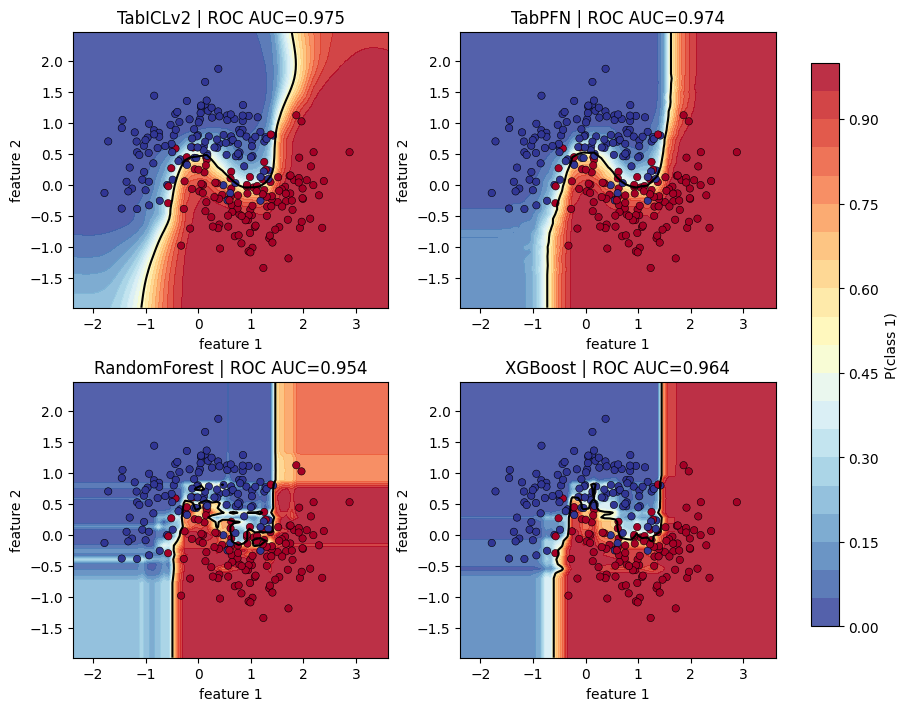

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
axes = axes.ravel()

for ax, (name, estimator) in zip(axes, surface_models.items()):
    estimator.fit(X_train_moons, y_train_moons)
    test_proba = positive_class_proba(estimator, X_test_moons)
    grid_proba = predict_proba_in_chunks(estimator, grid, chunk_size=2048)
    Z = grid_proba.reshape(xx.shape)

    contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.85)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5)
    ax.scatter(
        X_test_moons[:, 0],
        X_test_moons[:, 1],
        c=y_test_moons,
        cmap="RdYlBu_r",
        edgecolors="black",
        linewidths=0.4,
        s=28,
    )
    auc = roc_auc_score(y_test_moons, test_proba)
    ax.set_title(f"{name} | ROC AUC={auc:.3f}")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

fig.colorbar(contour, ax=axes, label="P(class 1)", shrink=0.9)
plt.show()

## 4. Quantile regression with TabICLv2 and TabPFN

This section compares predictive intervals on a synthetic heteroscedastic regression problem. The key feature is that both `TabICLRegressor` and `TabPFNRegressor` can return quantiles of the predictive distribution.

In [ ]:
rng = np.random.default_rng(SEED)
x = rng.uniform(low=-3, high=3, size=HETEROSCEDASTIC_SAMPLES)
X_het = x.reshape(-1, 1)


def true_y_mean(x_values):
    return expit(x_values) - 0.5 - 0.1 * x_values


def true_y_std(x_values):
    return 0.07 * np.exp(-((x_values - 0.5) ** 2) / 0.9)


y_het = rng.normal(loc=true_y_mean(x), scale=true_y_std(x))

X_train_het, X_test_het, y_train_het, y_test_het = train_test_split(
    X_het,
    y_het,
    test_size=0.5,
    random_state=SEED,
)

alphas = [0.10, 0.50, 0.90]

In [ ]:
quantile_models = {
    "TabICLv2": make_tabicl_regressor(),
    "TabPFN": make_tabpfn_regressor(),
}

quantile_predictions = {}
quantile_rows = []

for name, estimator in quantile_models.items():
    estimator.fit(X_train_het, y_train_het)
    if name == "TabICLv2":
        q = estimator.predict(X_test_het, output_type="quantiles", alphas=alphas)
    else:
        q = estimator.predict(X_test_het, output_type="quantiles", quantiles=alphas)
    q = coerce_quantile_array(q)
    quantile_predictions[name] = q

    lower, median, upper = q[:, 0], q[:, 1], q[:, 2]
    quantile_rows.append(
        {
            "model": name,
            "median_rmse": rmse(y_test_het, median),
            "interval_10_90_coverage": np.mean((y_test_het >= lower) & (y_test_het <= upper)),
            "mean_interval_width": np.mean(upper - lower),
        }
    )

quantile_summary = pd.DataFrame(quantile_rows)
quantile_summary

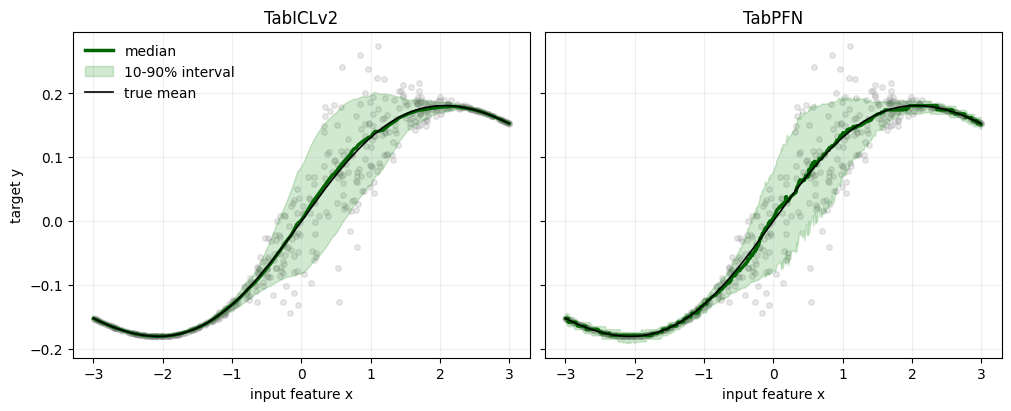

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True, sharey=True)

for ax, (name, q) in zip(axes, quantile_predictions.items()):
    order = np.argsort(X_test_het[:, 0])
    x_sorted = X_test_het[order, 0]
    q_sorted = q[order]

    ax.scatter(X_test_het[:, 0], y_test_het, alpha=0.18, s=16, color="gray")
    ax.plot(x_sorted, q_sorted[:, 1], color="darkgreen", linewidth=2.5, label="median")
    ax.fill_between(
        x_sorted,
        q_sorted[:, 0],
        q_sorted[:, 2],
        color="green",
        alpha=0.18,
        label="10-90% interval",
    )
    ax.plot(x_sorted, true_y_mean(x_sorted), color="black", linewidth=1.2, label="true mean")
    ax.set_title(name)
    ax.set_xlabel("input feature x")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("target y")
axes[0].legend(frameon=False)
plt.show()